In [ ]:
import numpy as np
import torch

from jordan_transformer.jordan import *
import matplotlib.pyplot as plt
import re
import os

In [ ]:
from plt_dict import matplotlib_update
matplotlib_update()

In [26]:
np.random.seed(1234)
torch.manual_seed(1234)
random.seed(1234)

# 1. 

In [ ]:
model = JordanNet(encode_dim=32)
pretrained_dimensions = [4, 6, 9, 12, 15, 28] + [35, 33, 25, 23, 19, 13, 7]
for dim in pretrained_dimensions:
    model.add_dimension(dim)

model.load_state_dict(torch.load(f"jordan_transformer/model_jordan_modified.pth", map_location="cpu"))
model.eval()

C:\Users\micha\AppData\Local\Temp\ipykernel_12732\485095138.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan_modif

JordanNet(
  (encoders): ModuleDict(
    (4): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=16, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (6): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=36, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (9): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=81, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias

In [28]:
def test_matrix(A):
    
    # print(np.linalg.eigvals(A))
    d = A.shape[0]
    features = [per_power_features(A)]
    if not np.max(check_doubling_consistency(features[0])[0]) <= 1e-9:
        return None
    features = [x.reshape(d, d*d) for x in features]
    features = torch.tensor(features, dtype=torch.float32)
    logits = model(d, features)
    probs = torch.softmax(logits, dim=-1)
    
    return probs

In [29]:
def run_test(eps):
    T1 = np.zeros((4,4))
    T1[:2,0] = np.random.randn(2)
    T1[:2,2] = np.random.randn(2)

    H1 = np.zeros((4,4))
    H1[0,0], H1[1,1], H1[3,2], H1[2,3] = 1, 1, 1, 1

    K1 = np.zeros((4,4)) + np.diag(np.ones(2), k=2) + np.diag(np.ones(2), k=-2)

    H2 = np.zeros((8,8))
    H2[:4, :4] = H1
    H2[4:6, 6:8] = np.eye(2)
    H2[6:8, 4:6] = np.eye(2)

    K2 = np.zeros((8,8))
    K2[:4, :4] = K1
    K2[4:6, 6:8] = np.eye(2)
    K2[6:8, 4:6] = np.eye(2)

    T2 = np.zeros((8,8))
    T2[:4,:4] = T1
    T2[:4,5:7] = np.random.randn(4,2)
    T2[5:7,:4] = np.random.randn(2,4)
    T2[5:7,5:7] = np.random.randn(2,2)

    T2_star = H2 @ T2.T @ K2
    TTstar = np.zeros((9,9))
    TTstar[:8,:8] = T2 @ T2_star

    TstarT = np.zeros((9,9))
    TstarT[:8,:8] = T2_star @ T2

    E = np.random.randn(9, 9)
    E /= np.linalg.norm(E)
    E *= eps
    A = TstarT + E
    rad1 = np.max(np.abs(np.linalg.eigvals(A)))
    print(rad1)
    if rad1 > 1:
        A /= rad1
        rad1 = 1
    prob1 = test_matrix(A)
    if prob1 is None:
        cls1 = torch.nan
    else:
        cls1 = torch.argmax(prob1).item()
    E = np.random.randn(9, 9)
    E /= np.linalg.norm(E)
    E *= eps
    A = TTstar + E
    rad2 = np.max(np.abs(np.linalg.eigvals(A)))
    print(rad2)
    if rad2 > 1:
        A /= rad2
        rad2 = 1
    prob2 = test_matrix(A)
    if prob2 is None:
        cls2 = torch.nan
    else:
        cls2 = torch.argmax(prob2).item()

    H3 = np.zeros((13,13))
    H3[:8,:8] = H2
    H3[8, 8] = 1
    H3[9:11, 11:] = np.eye(2)
    H3[11:, 9:11] = np.eye(2)

    K3 = np.zeros((12,12))
    K3[:8,:8] = K2
    K3[8:10, 10:] = np.eye(2)
    K3[10:, 8:10] = np.eye(2)

    T3 = np.zeros((12, 13))
    T3[:8, :8] = T2
    T3[:8, 9:11] = np.random.randn(8,2)
    T3[8:10, :8] = np.random.randn(2,8)
    T3[8:10, 9:11] = np.random.randn(2,2)

    T3_star = H3 @ T3.T @ K3

    TstarT = T3_star @ T3
    TTstar = T3 @ T3_star
    E = np.random.randn(13, 13)
    E /= np.linalg.norm(E)
    E *= eps
    A = TstarT + E
    rad3 = np.max(np.abs(np.linalg.eigvals(A)))
    print(rad3)
    if rad3 > 1:
        A /= rad3
        rad3 = 1
    prob3 = test_matrix(A)
    if prob3 is None:
        cls3 = torch.nan
    else:
        cls3 = torch.argmax(prob3).item()
    E = np.random.randn(12, 12)
    E /= np.linalg.norm(E)
    E *= eps
    A = TTstar + E
    rad4 = np.max(np.abs(np.linalg.eigvals(A)))
    print(rad4)
    if rad4 > 1:
        A /= rad4
        rad4 = 1
    prob4 = test_matrix(A)
    if prob4 is None:
        cls4 = torch.nan
    else:
        cls4 = torch.argmax(prob4).item()

    # plt.plot(prob2.detach().numpy()[0])
    # plt.xticks(ticks=range(12), labels=range(1, 13))
    # plt.show()

    return ((cls1, rad1), (cls2, rad2), (cls3, rad3), (cls4, rad4)) # should return (2, 1, 2, 3)


In [30]:
np.random.seed(1234)
random.seed(1234)
torch.manual_seed(1234)

In [31]:
# eps = 1e-5
results = np.array([run_test(np.exp(np.random.uniform(np.log(1e-7), np.log(1e-3)))) for _ in range(10_000)])

0.008347610792873229
0.0007695757816077311
0.01158407461609899
0.037064639521968534
0.004369093035157764
0.00045662365347466085
0.0066915189919380825
0.012244294432116408
0.001988845796989859
0.0009284317642043959
0.010266018246628058
0.012036904108183522
0.015069027406524688
0.004088536691109241
0.00970952848609695
0.034711158196517225
0.009514285290139795
0.000999119732154247
0.012840685018905491
0.03491625312619546
0.0015434589295074829
0.0003186825772633283
0.003950654803063509
0.006983779405042991
0.04678358196384032
0.00572869529172908
0.05290100312096341
0.036067380211526695
0.004563388766805394
0.0005038326714548358
0.004043277810543674
0.019302578620774034
0.00307569316339553
0.00021781141903014586
0.00512583792410781
0.010527276012136513
0.07099932909918867
0.014115701840312255
0.07661332663498475
0.12196140749417009
0.001701486228155993
0.00026350972356973406
0.005522654226774594
0.00974561991361817
0.002437874051522376
0.000255979289088111
0.005023131204875939
0.01248570641

In [32]:
def calculate_metrics(results, rad_bins=3, matrix_labels=None):
    """Compute accuracy metrics grouped by matrix type and spectral-radius bins.

    Expects results shaped like (num_samples, num_matrices, 2), where the last
    dimension stores (prediction, spectral_radius). Bins are computed separately
    for each matrix type so that each type can use its own radius range.
    """
    if isinstance(results, dict):
        return {key: calculate_metrics(value, rad_bins=rad_bins, matrix_labels=matrix_labels) for key, value in results.items()}

    true_output = np.array([2, 1, 2, 3])
    results = np.asarray(results, dtype=float)

    if results.ndim == 3 and results.shape[-1] >= 2:
        predictions = results[..., 0]
        radii = results[..., 1]
    elif results.ndim == 2:
        predictions = results
        radii = None
    else:
        raise ValueError("results must be a 2D prediction matrix or a 3D array with prediction/radius pairs")

    num_matrices = predictions.shape[1]
    if matrix_labels is None:
        matrix_labels = [f"matrix_{idx + 1}" for idx in range(num_matrices)]
    if len(matrix_labels) != num_matrices:
        raise ValueError("matrix_labels must have one label per matrix type")

    def resolve_bin_spec(label, col_idx):
        if isinstance(rad_bins, dict):
            if label in rad_bins:
                return rad_bins[label]
            if col_idx in rad_bins:
                return rad_bins[col_idx]
            if str(col_idx) in rad_bins:
                return rad_bins[str(col_idx)]
            if "default" in rad_bins:
                return rad_bins["default"]
            raise KeyError(f"No bin specification provided for matrix type {label!r}")
        return rad_bins

    def summarize(col_idx, mask):
        valid_mask = mask & ~np.isnan(predictions[:, col_idx])
        valid_predictions = predictions[:, col_idx][valid_mask]
        num_valid_samples = valid_predictions.size

        if num_valid_samples == 0:
            return {
                "exact_accuracy": np.nan,
                "accuracy_plus_minus_1": np.nan,
                "num_valid_examples": 0,
            }

        true_val = true_output[col_idx]
        exact_matches = np.sum(valid_predictions == true_val)
        within_one = np.sum(np.abs(valid_predictions - true_val) <= 1)

        return {
            "exact_accuracy": exact_matches / num_valid_samples,
            "accuracy_plus_minus_1": within_one / num_valid_samples,
            "num_valid_examples": int(num_valid_samples),
        }

    def build_bins(col_radii, bin_spec):
        finite_radii = col_radii[np.isfinite(col_radii)]
        if finite_radii.size == 0:
            raise ValueError("No finite spectral radii available for binning.")

        if np.isscalar(bin_spec):
            num_bins = int(bin_spec)
            if num_bins < 1:
                raise ValueError("rad_bins must be a positive integer or an array of bin edges")
            rad_min = float(np.min(finite_radii))
            rad_max = float(np.max(finite_radii))
            if np.isclose(rad_min, rad_max):
                rad_max = np.nextafter(rad_max, np.inf)
            bins = np.linspace(rad_min, rad_max, num_bins + 1)
        else:
            bins = np.asarray(bin_spec, dtype=float)
            if bins.ndim != 1 or bins.size < 2:
                raise ValueError("rad_bins must contain at least two bin edges")

        radius_bins = []
        for bin_idx, (left, right) in enumerate(zip(bins[:-1], bins[1:])):
            is_last_bin = bin_idx == len(bins) - 2
            if is_last_bin:
                bin_mask = (col_radii >= left) & (col_radii <= right)
            else:
                bin_mask = (col_radii >= left) & (col_radii < right)

            radius_bins.append(
                {
                    "radius_interval": (float(left), float(right)),
                    "is_last_bin": is_last_bin,
                    **summarize(col_idx, bin_mask),
                }
            )

        return radius_bins

    metrics_summary = {}
    for col_idx, label in enumerate(matrix_labels):
        if radii is None:
            metrics_summary[label] = {
                "radius_bins": [
                    {
                        "radius_interval": None,
                        "is_last_bin": True,
                        **summarize(col_idx, np.ones(predictions.shape[0], dtype=bool)),
                    }
                ]
            }
        else:
            bin_spec = resolve_bin_spec(label, col_idx)
            metrics_summary[label] = {"radius_bins": build_bins(radii[:, col_idx], bin_spec)}

    return metrics_summary

matrix_labels = ["T* T", "T T*", "T* T (13x13)", "T T* (12x12)"]
rad_bins = {
    "T* T": [0.0, 0.01, 0.03, 1.0],
    "T T*": [0.0, 0.01, 0.03, 1.0],
    "T* T (13x13)": [0.0, 0.01, 0.03, 1.0],
    "T T* (12x12)": [0.0, 0.01, 0.03, 1.0],
    "default": 3,
}
results_metrics = calculate_metrics(results, rad_bins=rad_bins, matrix_labels=matrix_labels)

In [33]:
for matrix_type, metrics in results_metrics.items():
    print(f"=== Matrix type: {matrix_type} ===")
    for bin_metrics in metrics["radius_bins"]:
        radius_interval = bin_metrics["radius_interval"]
        if radius_interval is None:
            interval_text = "all radii"
        else:
            left, right = radius_interval
            interval_text = f"[{left:.6g}, {right:.6g}{']' if bin_metrics['is_last_bin'] else ')'}"

        print(f"  Radius bin: {interval_text}")
        print(f"  Valid examples:              {bin_metrics['num_valid_examples']}")
        print(f"  Exact accuracy:              {bin_metrics['exact_accuracy']}")
        print(f"  Accuracy @ ±1:               {bin_metrics['accuracy_plus_minus_1']}")
    print()

=== Matrix type: T* T ===
  Radius bin: [0, 0.01)
  Valid examples:              5101
  Exact accuracy:              0.6583022936679083
  Accuracy @ ±1:               0.9903940403842384
  Radius bin: [0.01, 0.03)
  Valid examples:              3196
  Exact accuracy:              0.8063204005006258
  Accuracy @ ±1:               0.996558197747184
  Radius bin: [0.03, 1]
  Valid examples:              1700
  Exact accuracy:              0.9670588235294117
  Accuracy @ ±1:               1.0

=== Matrix type: T T* ===
  Radius bin: [0, 0.01)
  Valid examples:              8086
  Exact accuracy:              0.9988869651249073
  Accuracy @ ±1:               1.0
  Radius bin: [0.01, 0.03)
  Valid examples:              1755
  Exact accuracy:              1.0
  Accuracy @ ±1:               1.0
  Radius bin: [0.03, 1]
  Valid examples:              107
  Exact accuracy:              1.0
  Accuracy @ ±1:               1.0

=== Matrix type: T* T (13x13) ===
  Radius bin: [0, 0.01)
  Valid exampl

# 2.

In [249]:
import pandas as pd

In [250]:
np.random.seed(123)

In [251]:
def naive_classifier(A, eps): 
    k = 1
    d = A.shape[0]
    A_pow = np.eye(d)
    rk_prev = d
    while k < d:
        A_pow = A_pow @ A
        rk = np.linalg.matrix_rank(A_pow, rtol=eps*d if eps > 0 else None)
        # print(k, rk)
        if rk == 0 or rk > rk_prev:
            return k
        else:
            rk_prev = rk
            k += 1
    return k

In [252]:
d = 28 
naive_results = []
for m in range(1, d+1):
    for _ in range(1000):
        if np.random.uniform(0, 1) < 0.1:
            eps = 0.0
        else:
            eps = np.exp(np.random.uniform(np.log(1e-8), np.log(0.1)))

        A, rad, _ = generate_matrix(d, m, 'random', eps)
        if rad > 1:
            rad /= rad
            A /= rad
        pred = naive_classifier(A, eps)
        res = {
            "true_class": m,
            "pred_class": pred,
            "rad": rad,
            "E_norm": eps,
        }
        naive_results.append(res)

naive_results = pd.DataFrame(naive_results)

In [253]:
naive_results.describe()

,true_class,pred_class,rad,E_norm
count,28000.000000,28000.000000,28000.000000,2.800000e+04
mean,14.500000,12.687964,0.361616,5.668431e-03
std,8.077891,8.869131,0.268084,1.582886e-02
min,1.000000,1.000000,0.000000,0.000000e+00
25%,7.750000,4.000000,0.087578,1.519172e-07
50%,14.500000,11.000000,0.381811,1.334740e-05
75%,21.250000,20.000000,0.576774,1.171385e-03
max,28.000000,28.000000,0.944533,9.983364e-02


In [ ]:
def load_results_csvs(folder_path):
    """
    Reads all CSV files named results_{d}.csv (d = 1 or 2 digits)
    from the given folder and returns a dict of DataFrames.

    Returns:
        dict[int, pd.DataFrame]: {d: dataframe}
    """
    pattern = re.compile(r"^results_(\d{1,2})\.csv$")
    data = {}

    for filename in os.listdir(folder_path):
        match = pattern.match(filename)
        if match:
            d = int(match.group(1))
            file_path = os.path.join(folder_path, filename)
            df = pd.read_csv(file_path)
            data[d] = df

    return data

nn_results = load_results_csvs("./jordan_transformer/jordan_results")[28]

In [255]:
naive_results.head()

,true_class,pred_class,rad,E_norm
0,1,28,5.150229e-07,0.000001
1,1,2,1.360443e-04,0.000239
2,1,1,1.998707e-02,0.036774
3,1,4,9.793301e-04,0.001699
4,1,1,0.000000e+00,0.000000


In [256]:
nn_results = nn_results[nn_results["E_norm"]<= 0.1]
naive_results = naive_results[naive_results["E_norm"]<= 0.1]

In [257]:
naive_results.describe()

,true_class,pred_class,rad,E_norm
count,28000.000000,28000.000000,28000.000000,2.800000e+04
mean,14.500000,12.687964,0.361616,5.668431e-03
std,8.077891,8.869131,0.268084,1.582886e-02
min,1.000000,1.000000,0.000000,0.000000e+00
25%,7.750000,4.000000,0.087578,1.519172e-07
50%,14.500000,11.000000,0.381811,1.334740e-05
75%,21.250000,20.000000,0.576774,1.171385e-03
max,28.000000,28.000000,0.944533,9.983364e-02


In [258]:
nn_results.describe()

,true_class,pred_class,kl_loss,E_norm,S_cond,rad
count,280000.000000,280000.000000,280000.000000,280000.000000,280000.000000,280000.000000
mean,13.500000,13.500364,0.060238,0.006711,252.081035,0.389390
std,8.077762,8.077223,0.187169,0.017028,511.723409,0.255200
min,0.000000,0.000000,0.000001,0.000000,12.118155,0.000000
25%,6.750000,7.000000,0.002550,0.000001,56.886024,0.164374
50%,13.500000,14.000000,0.007209,0.000056,99.234824,0.413866
75%,20.250000,21.000000,0.030788,0.002419,211.447916,0.585677
max,27.000000,27.000000,11.095610,0.099997,5598.532682,0.947335


In [259]:

def plot_acc_vs_metric(
    ax,
    df,
    metric="E_norm",
    bins=None,
    k=1,
    s="Model",
    color="tab:blue",
    marker=None,
):
    required = {"true_class", "pred_class", metric}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    data = df[["true_class", "pred_class", metric]].dropna().copy()

    # ----------------------------
    # DEFAULT BIN STRUCTURE
    # ----------------------------
    if bins is None:
        bins = np.r_[0, np.logspace(-10, -1, 10)]

    bins = np.asarray(bins)

    # ensure sorted
    bins = np.unique(bins)
    bins.sort()

    # ----------------------------
    # ASSIGN BINS
    # ----------------------------
    data["bin"] = pd.cut(
        data[metric],
        bins=bins,
        include_lowest=True,
        right=True,
    )

    data["acc"] = data["true_class"] == data["pred_class"]
    data["acc_k"] = np.abs(data["true_class"] - data["pred_class"]) <= k

    grouped = data.groupby("bin", observed=True)

    # ----------------------------
    # BIN CENTERS (IMPORTANT FIX)
    # ----------------------------
    left = grouped[metric].min()
    right = grouped[metric].max()

    # geometric mean for log bins, arithmetic for zero bin
    centers = []
    for l, r in zip(left, right):
        if l == 0 or np.isnan(l):
            centers.append(0)  # Directly at 0
        else:
            centers.append(np.sqrt(l * r))

    result = pd.DataFrame({
        "x": centers,
        "acc": grouped["acc"].mean().values,
        "acc_k": grouped["acc_k"].mean().values,
        "count": grouped.size().values,
    })

    # ----------------------------
    # PLOT
    # ----------------------------
    ax.plot(
        result["x"],
        result["acc"],
        linestyle="-",
        marker=marker,
        color=color,
        label=f"{s} (Acc)",
    )

    ax.plot(
        result["x"],
        result["acc_k"],
        linestyle=":",
        marker=marker,
        linewidth=2,
        color=color,
        label=f"{s} (Acc@$\\pm${k})",
    )
    return result

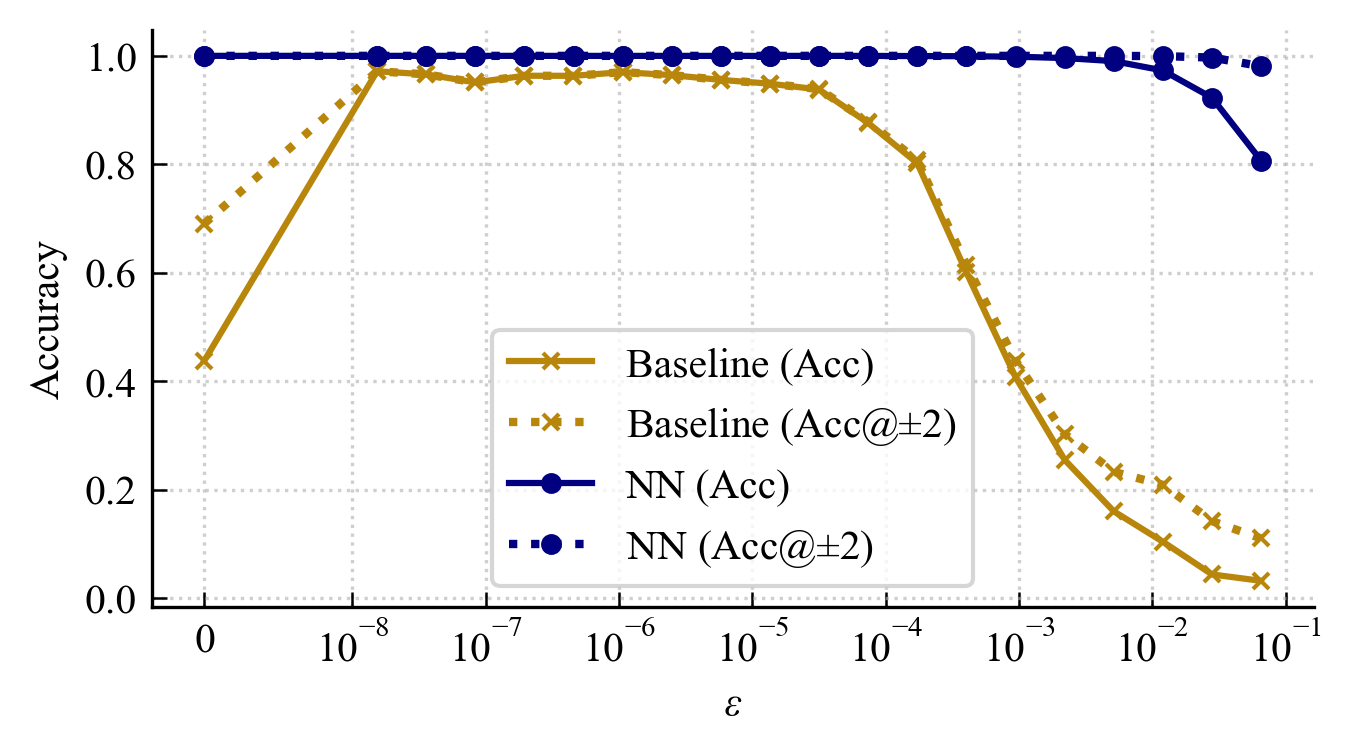

In [260]:
fig, ax = plt.subplots(figsize=(5, 2.5))

bins = np.r_[0, np.logspace(-8, -1, 20)]

plot_acc_vs_metric(
    ax=ax,
    df=naive_results,
    metric="E_norm",
    bins=bins,
    k=2,
    s="Baseline",
    color="darkgoldenrod",
    marker="x"
)

plot_acc_vs_metric(
    ax=ax,
    df=nn_results,
    metric="E_norm",
    bins=bins,
    k=2,
    s="NN",
    color="navy",
    marker="o"
)

ax.set_xscale("symlog", linthresh=1e-8)
ax.legend()
ax.set_xlabel("$\\varepsilon$")
ax.set_ylabel("Accuracy")
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig("latex/images/j8_naive_a.pdf")
plt.show()

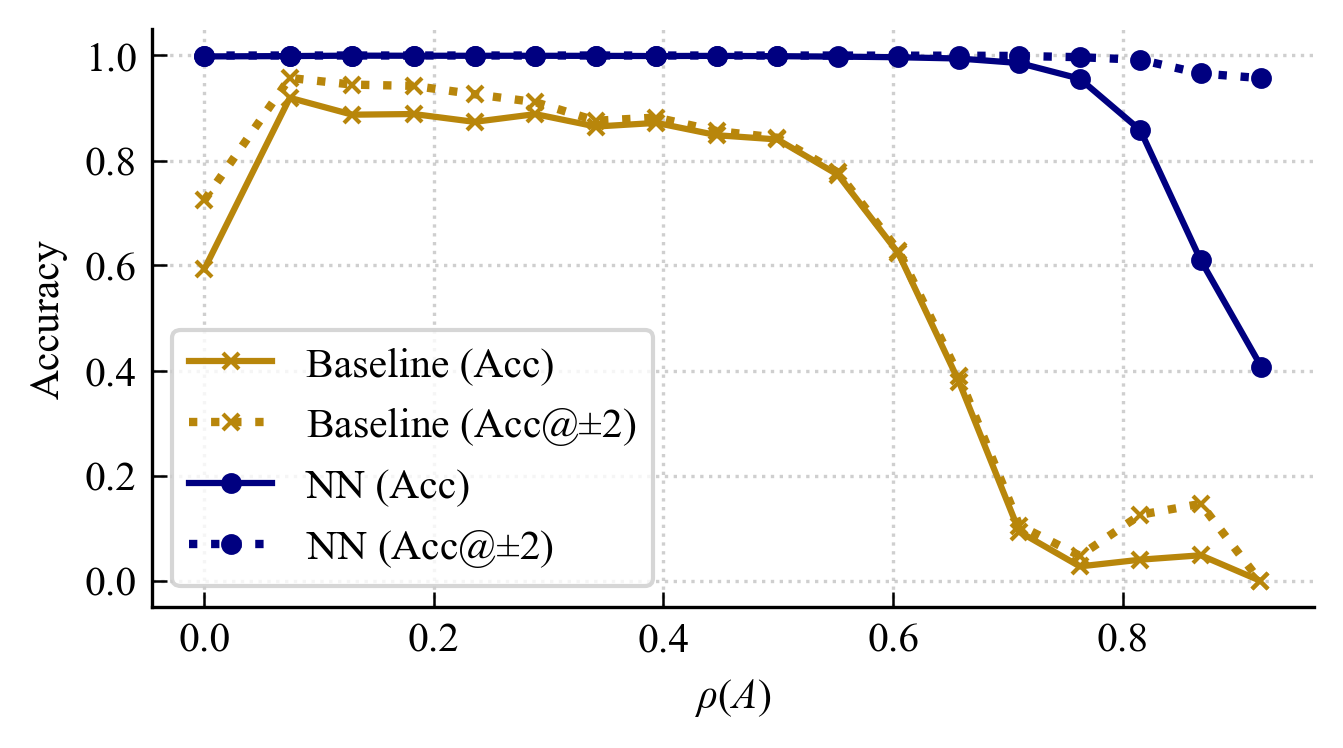

In [261]:
fig, ax = plt.subplots(figsize=(5, 2.5))

bins = np.linspace(0, 1, 20)

df = plot_acc_vs_metric(
    ax=ax,
    df=naive_results,
    metric="rad",
    bins=bins,
    k=2,
    s="Baseline",
    color="darkgoldenrod",
    marker="x"
)

plot_acc_vs_metric(
    ax=ax,
    df=nn_results,
    metric="rad",
    bins=bins,
    k=2,
    s="NN",
    color="navy",
    marker="o"
)

ax.legend()
ax.set_xlabel("$\\rho(A)$")
ax.set_ylabel("Accuracy")
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig("latex/images/j8_naive_b.pdf")
plt.show()